In [ ]:
import os
import pandas as pd
import numpy as np   
import re 
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.validation import make_valid
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

path_to_scenarios = '/home/abhis/india_power/scenarios'
path_to_save_images = '/home/abhis/india_power/images'
path_to_data = '/home/abhis/india_power/gridpath_india_viz/data/'
# Define scenario names explicitly or detect automatically
# scenario_names = ['iced_2050_cc_1','iced_2050_cc_2','iced_2050_cc_3'] # Example: Explicit list
# scenario_names = ['pier_mid_ra_2040_1','pier_mid_ra_2040_2','pier_mid_ra_2040_3'] # Example: Explicit list
# scenario_names = ['iced_mid_ra_2040_1','iced_mid_ra_2040_2','iced_mid_ra_2040_3'] # Example: Explicit list

scenario_names = ['capex_pier_prm_108_cc_90_hardovergen_2040_1','capex_pier_prm_108_cc_90_hardovergen_2040_2','capex_pier_prm_108_cc_90_hardovergen_2040_3',
                'capex_pier_prm_108_cc_90_hardovergen_2040_4','capex_pier_prm_108_cc_90_hardovergen_2040_5','capex_pier_prm_108_cc_90_hardovergen_2040_6',
                'capex_pier_prm_108_cc_90_hardovergen_2040_7','capex_pier_prm_108_cc_90_hardovergen_2040_8','capex_pier_prm_108_cc_90_hardovergen_2040_9',
                'capex_pier_prm_108_cc_90_hardovergen_2040_10','capex_pier_prm_108_cc_90_hardovergen_2040_11','capex_pier_prm_108_cc_90_hardovergen_2040_12',
                'capex_pier_prm_108_cc_90_hardovergen_2040_13','capex_pier_prm_108_cc_90_hardovergen_2040_14','capex_pier_prm_108_cc_90_hardovergen_2040_15',
                'capex_pier_prm_108_cc_90_hardovergen_2040_16','capex_pier_prm_108_cc_90_hardovergen_2040_17','capex_pier_prm_108_cc_90_hardovergen_2040_18'] # Example: Explicit list



# Load system load timepoints from all the iterations 

In [2]:

print(f"Processing scenarios for system_load_zone_timepoint: {scenario_names}")

all_system_load_data = []

for scenario_name in scenario_names:
    scenario_path = os.path.join(path_to_scenarios, scenario_name)
    if not os.path.isdir(scenario_path):
        print(f"Warning: Scenario directory not found: {scenario_path}")
        continue

    for weather_folder in os.listdir(scenario_path):
        if not weather_folder.startswith('weather_iteration_'):
            continue
        weather_iteration = int(re.search(r'\d+', weather_folder).group())
        weather_path = os.path.join(scenario_path, weather_folder)

        for hydro_folder in os.listdir(weather_path):
            if not hydro_folder.startswith('hydro_iteration_'):
                continue
            hydro_iteration = int(re.search(r'\d+', hydro_folder).group())
            hydro_path = os.path.join(weather_path, hydro_folder)

            for avail_folder in os.listdir(hydro_path):
                if not avail_folder.startswith('availability_iteration_'):
                    continue
                availability_iteration = int(re.search(r'\d+', avail_folder).group())
                avail_path = os.path.join(hydro_path, avail_folder)

                csv_path = os.path.join(avail_path, 'results', 'system_load_zone_timepoint.csv')
                if os.path.exists(csv_path):
                    try:
                        df = pd.read_csv(csv_path)

                        # Tag with iteration info
                        df['scenario_name']         = scenario_name
                        df['weather_iteration']     = weather_iteration
                        df['hydro_iteration']       = hydro_iteration
                        df['availability_iteration'] = availability_iteration

                        all_system_load_data.append(df)
                    except Exception as e:
                        print(f"Error reading {csv_path}: {e}")
                else:
                    print(f"Warning: Missing CSV in {csv_path}")

# Combine into one DataFrame
if not all_system_load_data:
    raise RuntimeError("No system_load_zone_timepoint.csv files found.")
final_system_load_df = pd.concat(all_system_load_data, ignore_index=True)
print("Loaded all raw CSVs into final_system_load_df")

# Create a true timestamp column from your 'timepoint' field (YYYYMMDDHH)
tp = final_system_load_df['timepoint'].astype(str)
dates = tp.str[:8]
hours = tp.str[8:].astype(int) - 1  # HE01→0, HE24→23

final_system_load_df['timestamp'] = (
    pd.to_datetime(dates, format='%Y%m%d')
    + pd.to_timedelta(hours, unit='h')
)

# (Optional) If you no longer need the original timepoint string:
# final_system_load_df.drop(columns=['timepoint'], inplace=True)

# Reorder so timestamp is first
cols = final_system_load_df.columns.tolist()
cols.insert(0, cols.pop(cols.index('timestamp')))
final_system_load_df = final_system_load_df[cols]

print("Added timestamp column. Data is raw and ready for your aggregation.")
final_system_load_df.drop(columns=['number_years_represented', 'timepoint_weight', 'load_balance_dual', 'load_balance_marginal_cost_per_mw', 'scenario_name'], inplace=True)

print(final_system_load_df.head())

Processing scenarios for system_load_zone_timepoint: ['capex_pier_prm_108_cc_90_hardovergen_2040_1', 'capex_pier_prm_108_cc_90_hardovergen_2040_2', 'capex_pier_prm_108_cc_90_hardovergen_2040_3', 'capex_pier_prm_108_cc_90_hardovergen_2040_4', 'capex_pier_prm_108_cc_90_hardovergen_2040_5', 'capex_pier_prm_108_cc_90_hardovergen_2040_6', 'capex_pier_prm_108_cc_90_hardovergen_2040_7', 'capex_pier_prm_108_cc_90_hardovergen_2040_8', 'capex_pier_prm_108_cc_90_hardovergen_2040_9', 'capex_pier_prm_108_cc_90_hardovergen_2040_10', 'capex_pier_prm_108_cc_90_hardovergen_2040_11', 'capex_pier_prm_108_cc_90_hardovergen_2040_12', 'capex_pier_prm_108_cc_90_hardovergen_2040_13', 'capex_pier_prm_108_cc_90_hardovergen_2040_14', 'capex_pier_prm_108_cc_90_hardovergen_2040_15', 'capex_pier_prm_108_cc_90_hardovergen_2040_16', 'capex_pier_prm_108_cc_90_hardovergen_2040_17', 'capex_pier_prm_108_cc_90_hardovergen_2040_18']
Loaded all raw CSVs into final_system_load_df
Added timestamp column. Data is raw and ready

## National level RA metrics

In [3]:
selected_load_zone = 'national' # Options: 'national' or a specific load_zone name (e.g., 'Goa')

# Check if final_system_load_df exists and is not empty
if 'final_system_load_df' in locals() and not final_system_load_df.empty:
    if selected_load_zone.lower() == 'national':
        print(f"Aggregating system load for: National")
        # --- Aggregate for National ---
        # Define the columns to group by (timestamp, iterations, original timepoint)
        grouping_cols = ['timestamp', 'weather_iteration', 'hydro_iteration', 'availability_iteration', 'timepoint']
        # Define columns to sum
        summing_cols = ['static_load_mw', 'total_power_mw', 'net_imports_mw', 'overgeneration_mw', 'unserved_energy_mw']
        # Ensure grouping cols exist
        valid_grouping_cols = [col for col in grouping_cols if col in final_system_load_df.columns]
        if len(valid_grouping_cols) != len(grouping_cols):
            print(f"Warning: Missing grouping columns. Using: {valid_grouping_cols}")

        # Group by the defined columns and sum the relevant columns across original load zones
        aggregated_system_load_df = final_system_load_df.groupby(valid_grouping_cols, as_index=False)[summing_cols].sum()

        # Add the 'load_zone' column with 'national' value
        aggregated_system_load_df['load_zone'] = 'national'

        # Reorder columns: timestamp first, then iterations, timepoint, load_zone, summed columns
        final_cols_order = valid_grouping_cols + ['load_zone'] + summing_cols
        # Ensure all columns exist before reordering
        final_cols_order = [col for col in final_cols_order if col in aggregated_system_load_df.columns]
        aggregated_system_load_df = aggregated_system_load_df[final_cols_order]
        print("National aggregated system load DataFrame created successfully.")
        # -----------------------------
    else:
        print(f"Filtering system load for: {selected_load_zone}")
        # --- Filter for a specific load zone ---
        if 'load_zone' in final_system_load_df.columns:
            aggregated_system_load_df = final_system_load_df[final_system_load_df['load_zone'] == selected_load_zone].copy()
            if aggregated_system_load_df.empty:
                print(f"Warning: No data found for load zone '{selected_load_zone}'. Check spelling and data.")
            else:
                print(f"Filtered DataFrame for load zone '{selected_load_zone}' created successfully.")
                # Column order should already be correct from previous cell
        else:
            print("Error: 'load_zone' column not found in final_system_load_df. Cannot filter by specific zone.")
            aggregated_system_load_df = pd.DataFrame() # Create empty df to avoid errors later
        # ------------------------------------

    # Display the first few rows (optional)
    if not aggregated_system_load_df.empty:
        print("\nAggregated/Filtered DataFrame head:")
        print(aggregated_system_load_df.head())
else:
    print("final_system_load_df not found or is empty. Run the previous cell first.")
    aggregated_system_load_df = pd.DataFrame() # Ensure variable exists even if previous cell failed

Aggregating system load for: National
National aggregated system load DataFrame created successfully.

Aggregated/Filtered DataFrame head:
   timestamp  weather_iteration  hydro_iteration  availability_iteration  \
0 2040-04-01                  1                1                       1   
1 2040-04-01                  2                2                       2   
2 2040-04-01                  3                3                       3   
3 2040-04-01                  4                4                       4   
4 2040-04-01                  5                5                       5   

    timepoint load_zone  static_load_mw  total_power_mw  net_imports_mw  \
0  2040040101  national   356639.894731   360266.026778    -3626.132047   
1  2040040101  national   344471.731626   348557.925327    -4086.193701   
2  2040040101  national   333142.308974   336711.603864    -3569.294890   
3  2040040101  national   346976.546262   352467.652978    -5491.106715   
4  2040040101  national   347

In [4]:
# Copy the raw data
df = aggregated_system_load_df.copy()

# 1. Flag loss‐of‐load hours and extract date
df['is_lol']    = df['unserved_energy_mw'] > 0
df['date']      = df['timestamp'].dt.date
df['hrs_in_tmp'] = 1  # each row is one hour

# 2. Compute number of simulation years
num_iters = (
    df['weather_iteration'].nunique()
    * df['hydro_iteration'].nunique()
    * df['availability_iteration'].nunique()
)
hrs_per_combo = df.loc[
    (df['weather_iteration'] == df['weather_iteration'].iloc[0]) &
    (df['hydro_iteration']   == df['hydro_iteration'].iloc[0])   &
    (df['availability_iteration'] == df['availability_iteration'].iloc[0]),
    'hrs_in_tmp'
].sum()
n_years = num_iters * hrs_per_combo / 8760

# 3. Compute core metrics
total_lol_hours  = df['is_lol'].sum()
LOLH             = total_lol_hours / n_years

total_unserved   = (df.loc[df['is_lol'], 'unserved_energy_mw'] 
                    * df.loc[df['is_lol'], 'hrs_in_tmp']).sum()
EUE              = total_unserved / n_years

days_with_lol    = df.groupby('date')['is_lol'].max().sum()
LOLE             = days_with_lol / n_years

years_with_lol   = (
    df.loc[df['is_lol'], 
           ['weather_iteration','hydro_iteration','availability_iteration']]
    .drop_duplicates()
    .shape[0]
)
LOLP             = years_with_lol / n_years

# 4. Compute Normalized Energy Not Served (NENS)
#    % of total system energy not served per year
total_system_energy = (
    (df['static_load_mw'] * df['hrs_in_tmp']).sum() / n_years
)
NENS = EUE / total_system_energy * 100  # percent of system load not served

national_metrics_df = pd.DataFrame({
    'metric': ['LOLH', 'EUE', 'LOLE', 'LOLP', 'NENS'],
    'value': [LOLH, EUE, LOLE, LOLP, NENS]
})

print("\nNational metrics DataFrame:")
print(national_metrics_df)


National metrics DataFrame:
  metric       value
0   LOLH    0.074588
1    EUE  129.069705
2   LOLE    0.015089
3   LOLP    0.003086
4   NENS    0.001076


## Zone level RA Metrics

In [5]:
# Aggregate metrics for each load zone separately

# If you want to include all original load zones, use the un-aggregated DataFrame
if 'final_system_load_df' not in locals() or final_system_load_df.empty:
    print("final_system_load_df not found or is empty. Run the previous cells first.")
else:
    # Prepare results list
    metrics = []

    # Get unique zones
    all_zones = final_system_load_df['load_zone'].unique()

    for zone in all_zones:
        df = final_system_load_df[final_system_load_df['load_zone'] == zone].copy()
        df['is_lol']    = df['unserved_energy_mw'] > 0
        df['date']      = df['timestamp'].dt.date
        df['hrs_in_tmp'] = 1

        num_iters = (
            df['weather_iteration'].nunique()
            * df['hydro_iteration'].nunique()
            * df['availability_iteration'].nunique()
        )
        hrs_per_combo = df.loc[
            (df['weather_iteration'] == df['weather_iteration'].iloc[0]) &
            (df['hydro_iteration']   == df['hydro_iteration'].iloc[0])   &
            (df['availability_iteration'] == df['availability_iteration'].iloc[0]),
            'hrs_in_tmp'
        ].sum()
        n_years = num_iters * hrs_per_combo / 8760

        total_lol_hours  = df['is_lol'].sum()
        LOLH             = total_lol_hours / n_years

        total_unserved   = (df.loc[df['is_lol'], 'unserved_energy_mw'] 
                            * df.loc[df['is_lol'], 'hrs_in_tmp']).sum()
        EUE              = total_unserved / n_years

        days_with_lol    = df.groupby('date')['is_lol'].max().sum()
        LOLE             = days_with_lol / n_years

        years_with_lol   = (
            df.loc[df['is_lol'], 
                   ['weather_iteration','hydro_iteration','availability_iteration']]
            .drop_duplicates()
            .shape[0]
        )
        LOLP             = years_with_lol / n_years

        total_system_energy = (
            (df['static_load_mw'] * df['hrs_in_tmp']).sum() / n_years
        )
        NENS = EUE / total_system_energy * 100 if total_system_energy > 0 else np.nan

        metrics.append({
            'load_zone': zone,
            'LOLH (hrs/yr)': LOLH,
            'EUE (MWh/yr)': EUE,
            'LOLE (days/yr)': LOLE,
            'LOLP': LOLP,
            'NENS (%)': NENS
        })

    # Create summary DataFrame
    metrics_df = pd.DataFrame(metrics)
    print(metrics_df)
    

             load_zone  LOLH (hrs/yr)  EUE (MWh/yr)  LOLE (days/yr)      LOLP  \
0       Andhra_Pradesh       0.000857      1.169600        0.000514  0.000514   
1    Arunachal_Pradesh       0.000000      0.000000        0.000000  0.000000   
2                Assam       0.000000      0.000000        0.000000  0.000000   
3               Bhutan       0.000000      0.000000        0.000000  0.000000   
4                Bihar       0.000000      0.000000        0.000000  0.000000   
5           Chandigarh       0.003258      0.133653        0.002401  0.002229   
6         Chhattisgarh       0.000000      0.000000        0.000000  0.000000   
7   Dadra_Nagar_Haveli       0.064129     16.012508        0.014918  0.003086   
8            Daman_Diu       0.001886      0.543779        0.001029  0.000857   
9                Delhi       0.001029      0.792951        0.001029  0.000857   
10                 Goa       0.015604      9.651765        0.006344  0.002743   
11             Gujarat      

# Plot unserved energy

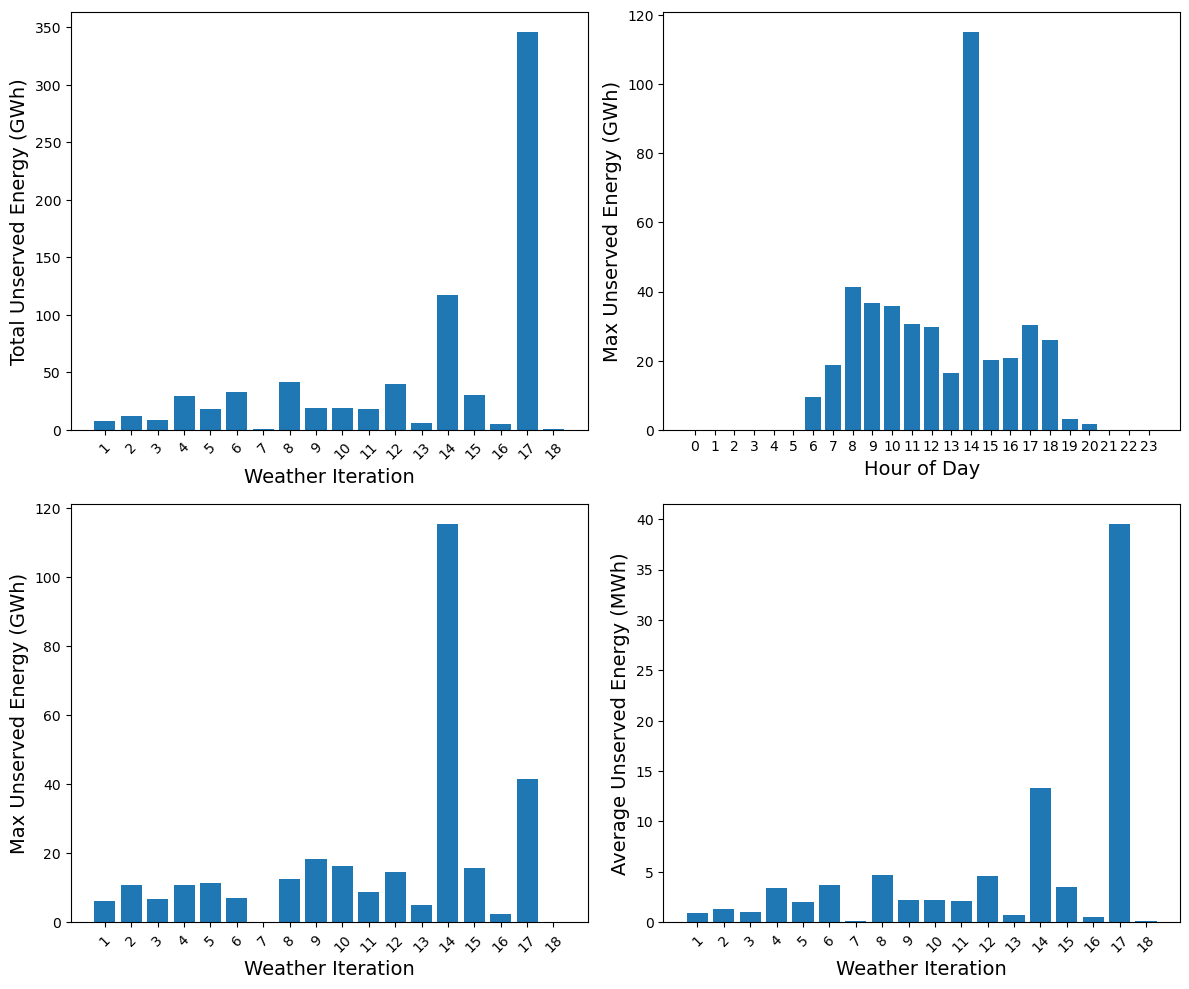

<Figure size 640x480 with 0 Axes>

In [12]:

# Prepare dataframe and calculated metrics
df = aggregated_system_load_df.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour

yearly_sum = df.groupby('weather_iteration')['unserved_energy_mw'].sum()
max_by_hour = df.groupby('hour')['unserved_energy_mw'].max()
yearly_max = df.groupby('weather_iteration')['unserved_energy_mw'].max()
yearly_avg = df.groupby('weather_iteration')['unserved_energy_mw'].mean()

# Create 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Total unserved energy by year
axes[0, 0].bar(yearly_sum.index.astype(str), yearly_sum/1000)  
# axes[0, 0].set_title(f'Total Unserved Energy by Weather Iteration\nLoad Zone: {selected_load_zone}')
axes[0, 0].set_xlabel('Weather Iteration', fontsize=14)
axes[0, 0].set_ylabel('Total Unserved Energy (GWh)', fontsize=14)
axes[0, 0].tick_params(axis='x', rotation=45)

# Max hourly unserved energy by hour
axes[0, 1].bar(max_by_hour.index, max_by_hour/1000)
# axes[0, 1].set_title('Max Hourly Unserved Energy Across All Weather Iteration')
axes[0, 1].set_xlabel('Hour of Day', fontsize=14)
axes[0, 1].set_ylabel('Max Unserved Energy (GWh)', fontsize=14)
axes[0, 1].set_xticks(range(0, 24))

# Max unserved energy in any hour by year
axes[1, 0].bar(yearly_max.index.astype(str), yearly_max/1000)
# axes[1, 0].set_title('Max Unserved Energy by Weather Iteration')
axes[1, 0].set_xlabel('Weather Iteration', fontsize=14)
axes[1, 0].set_ylabel('Max Unserved Energy (GWh)', fontsize=14)
axes[1, 0].tick_params(axis='x', rotation=45)

# Average hourly unserved energy by year
axes[1, 1].bar(yearly_avg.index.astype(str), yearly_avg)
# axes[1, 1].set_title('Average Hourly Unserved Energy by Weather Iteration')
axes[1, 1].set_xlabel('Weather Iteration', fontsize=14)
axes[1, 1].set_ylabel('Average Unserved Energy (MWh)', fontsize=14)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Save the figure
output_path = os.path.join(path_to_save_images, f'unserved_energy_{selected_load_zone}.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')



# # Print the data series for reference
# print("Total Unserved Energy (MWh) by Weather Year:")
# print(yearly_sum.to_string())
# print("\nMax Hourly Unserved Energy (MWh) Across All Weather Years:")
# print(max_by_hour.to_string())
# print("\nMax Unserved Energy (MWh) in a Single Hour by Weather Year:")
# print(yearly_max.to_string())
# print("\nAverage Hourly Unserved Energy (MWh) by Weather Year:")
# print(yearly_avg.to_string())


/tmp/ipykernel_3213358/2264541152.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  _nothern      = _india.loc[[4,10,11,22,24,25,30,31,35,36]].dissolve().buffer(.025)


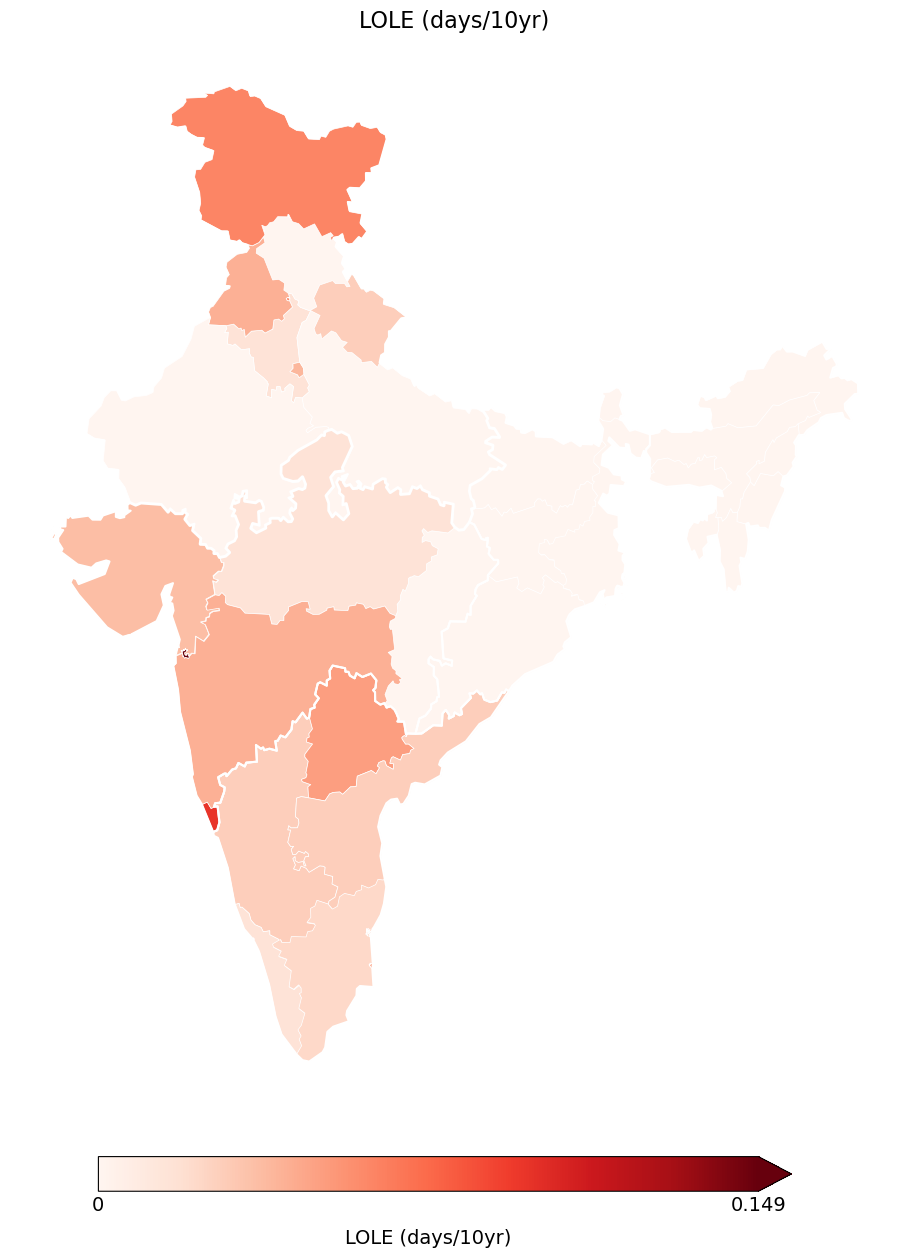

In [ ]:



_india  = gpd.read_file(path_to_data + r"map/india/india-polygon.shp").to_crs("epsg:4326")
_india['geometry'] = _india['geometry'].apply(lambda geom: make_valid(geom) if geom else None)
_india = _india.dropna(subset=['geometry'])

_india = _india.rename(columns={'st_nm': 'load_zone'})
_india['load_zone'] = _india['load_zone'].str.replace(" ", "_").str.replace("_and_", "_")


_nothern      = _india.loc[[4,10,11,22,24,25,30,31,35,36]].dissolve().buffer(.025)
_northeastern = _india.loc[[1,2,18,19,20,21,29]].dissolve()
_western      = _india.loc[[5,6,7,8,9,16,17]].dissolve()
_southern     = _india.loc[[13,14,23,27,28,34]].dissolve()
_eastern      = _india.loc[[3,12,26,32,33]].dissolve()


_india.loc[35, 'geometry'] = _india.loc[35, 'geometry'].union(_india.loc[36, 'geometry'])
_india = _india.drop([0,36]).reset_index(drop=True)
_india = pd.merge(_india, metrics_df, on='load_zone')

# Plot
metric = 'LOLE (days/yr)'
_cmap  = plt.get_cmap('Reds')
_norm  = plt.Normalize(vmin=0, vmax=np.sqrt(_india[metric].max()))

fig, ax = plt.subplots(figsize=(14,15))


for region in (_nothern, _northeastern, _western, _southern, _eastern):
    region.plot(ax=ax, zorder=9, color='None', lw=1.5, edgecolor='white')

for zone in _india['load_zone']:
    val = np.sqrt(_india.loc[_india['load_zone']==zone, metric].item())
    _india.loc[_india['load_zone']==zone].plot(
        ax=ax, zorder=8,
        color=_cmap(_norm(val)),
        lw=0.5, edgecolor='white'
    )

sm = cm.ScalarMappable(cmap=_cmap, norm=_norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax,
                    orientation='horizontal',
                    fraction=0.03, pad=0.04,
                    extend='max')
cbar.set_ticks([_norm.vmin, _norm.vmax])
cbar.set_ticklabels(['0',f'{_india[metric].max()*10:.3f}'],fontsize=14) # uncomment for LOLE
# cbar.set_ticklabels(['0',f'{_india[metric].max():.3f}'],fontsize=14)
cbar.ax.xaxis.set_tick_params(length=0)
# cbar.set_label(metric, rotation=0, labelpad=10,fontsize=14)
cbar.set_label('LOLE (days/10yr)', rotation=0, labelpad=10,fontsize=14) # uncomment for LOLE

# ax.set_title(metric, fontsize=20)
ax.set_title('LOLE (days/10yr)', fontsize=16) # uncomment for LOLE
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()


# heatmaps for RA Metrics

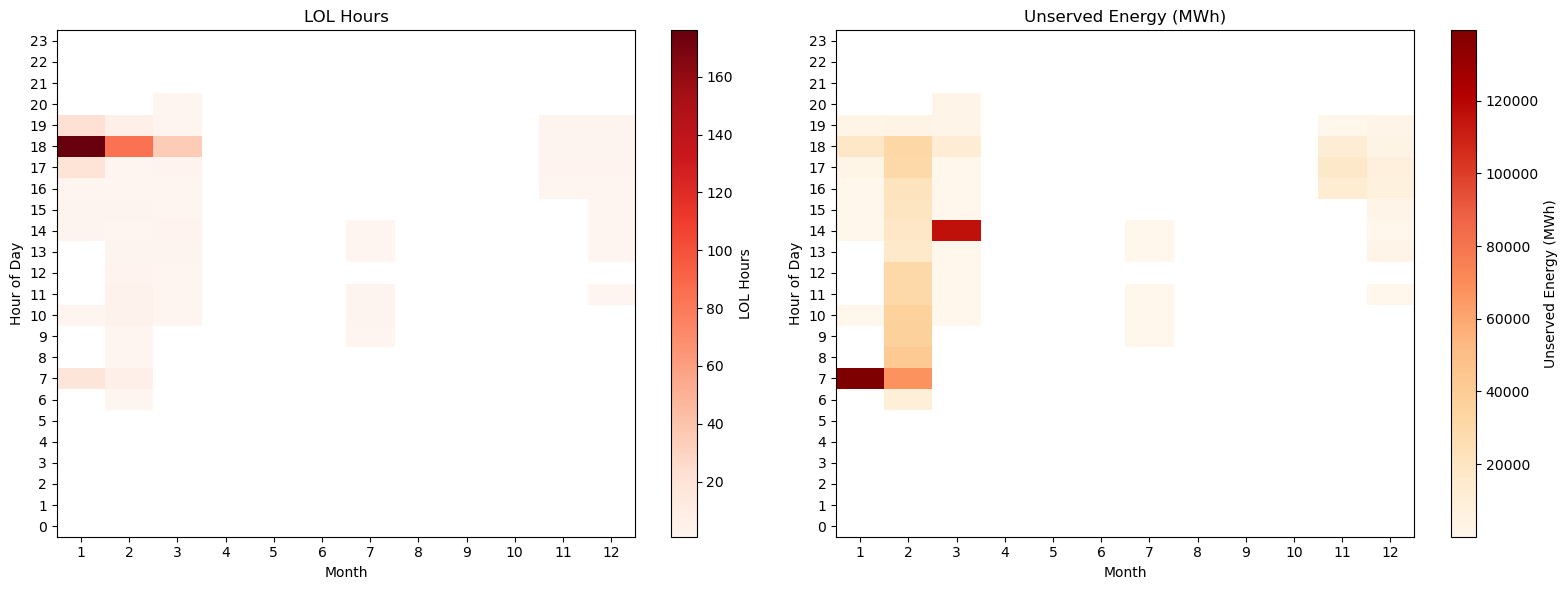

In [8]:
df_for_heatmap = aggregated_system_load_df.copy()
df_for_heatmap['is_lol'] = df_for_heatmap['unserved_energy_mw'] > 0
df_for_heatmap['month']  = df_for_heatmap['timestamp'].dt.month
df_for_heatmap['hour']   = df_for_heatmap['timestamp'].dt.hour

# 1. Heatmap for loss-of-load hours (count)
lol_counts = (
    df_for_heatmap[df_for_heatmap['is_lol']]
    .groupby(['hour', 'month'])
    .size()
)
lol_heatmap_df = (
    lol_counts
    .unstack(fill_value=0)
    .reindex(index=range(0, 24), columns=range(1, 13), fill_value=0)
)

# 2. Heatmap for total unserved energy (sum)
energy_sums = (
    df_for_heatmap
    .groupby(['hour', 'month'])['unserved_energy_mw']
    .sum()
)
energy_heatmap_df = (
    energy_sums
    .unstack(fill_value=0)
    .reindex(index=range(0, 24), columns=range(1, 13), fill_value=0)
)

# Mask zeros for both
lol_data = np.ma.masked_equal(lol_heatmap_df.values, 0)
energy_data = np.ma.masked_equal(energy_heatmap_df.values, 0)

# Configure colormaps
cmap_lol = plt.cm.Reds
cmap_lol.set_bad(color='white')
cmap_energy = plt.cm.OrRd
cmap_energy.set_bad(color='white')

# Plot side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Loss-of-Load Hours heatmap
im1 = ax1.imshow(lol_data, origin='lower', aspect='auto', cmap=cmap_lol)
ax1.set_title('LOL Hours')
ax1.set_xlabel('Month')
ax1.set_ylabel('Hour of Day')
ax1.set_xticks(np.arange(12))
ax1.set_xticklabels(np.arange(1, 13))
ax1.set_yticks(np.arange(24))
ax1.set_yticklabels(np.arange(0, 24))
fig.colorbar(im1, ax=ax1, label='LOL Hours')

# Unserved Energy heatmap
im2 = ax2.imshow(energy_data, origin='lower', aspect='auto', cmap=cmap_energy)
ax2.set_title('Unserved Energy (MWh)')
ax2.set_xlabel('Month')
ax2.set_ylabel('Hour of Day')
ax2.set_xticks(np.arange(12))
ax2.set_xticklabels(np.arange(1, 13))
ax2.set_yticks(np.arange(24))
ax2.set_yticklabels(np.arange(0, 24))
fig.colorbar(im2, ax=ax2, label='Unserved Energy (MWh)')

plt.tight_layout()
plt.show()


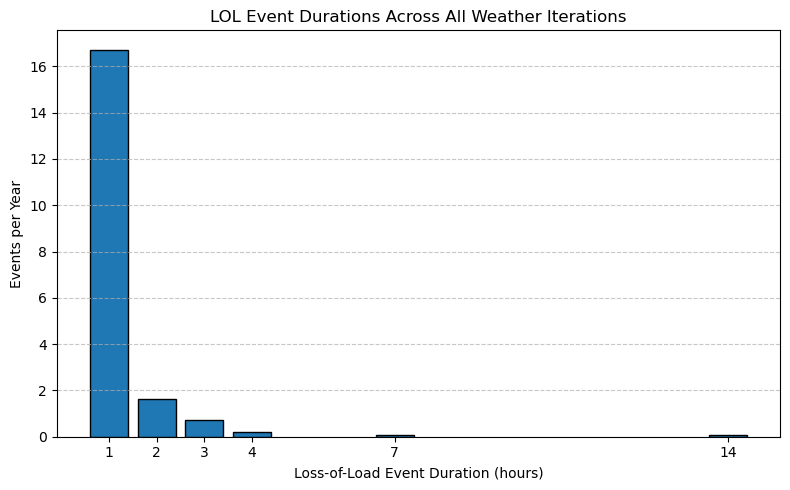

In [9]:
# 1. Prepare DataFrame
df = aggregated_system_load_df.copy()
df['is_lol'] = df['unserved_energy_mw'] > 0

# 2. Collect event durations across all weather_iterations
all_durations = []

for w in df['weather_iteration'].unique():
    sub = df[df['weather_iteration'] == w].sort_values('timestamp')
    sub['lol_start'] = (~sub['is_lol'].shift(fill_value=False)) & sub['is_lol']
    sub['event_id'] = sub['lol_start'].cumsum()
    durations = sub[sub['is_lol']].groupby('event_id').size().values
    all_durations.extend(durations)

event_durations = pd.Series(all_durations, name='duration')

# 3. Compute number of simulated years (weather_iterations count)
n_years = df['weather_iteration'].nunique()

# 4. Events per year by duration
events_per_year = event_durations.value_counts().sort_index() / n_years

# 5. Plot distribution
plt.figure(figsize=(8, 5))
plt.bar(events_per_year.index, events_per_year.values, edgecolor='black')
plt.xlabel('Loss-of-Load Event Duration (hours)')
plt.ylabel('Events per Year')
plt.title('LOL Event Durations Across All Weather Iterations')
plt.xticks(events_per_year.index)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
